In [73]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch

from lameg.surf import create_surf_gifti
from lameg.viz import show_surface, color_map, rgbtoint
from lameg.util import get_bigbrain_layer_boundaries, load_meg_sensor_data, convert_native_to_fsaverage
from scipy.signal import correlate
import io
from PIL import Image
from base64 import b64decode
from scipy.io import savemat, loadmat

In [74]:
plt.rcParams.update({
    'font.size': 16,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

In [75]:
vc_preproc_data_dir='/home/common/bonaiuto/cued_action_meg/derivatives/processed'
sp_preproc_data_dir='/home/common/bonaiuto/auditory_laminar/derivatives/processed/'

In [76]:
fsave_lh_coords, fsave_lh_faces = nib.freesurfer.io.read_geometry('/home/common/bonaiuto/cued_action_meg/derivatives/processed/fs/fsaverage/surf/lh.inflated')

In [77]:
%env SUBJECTS_DIR=/home/common/bonaiuto/cued_action_meg/derivatives/processed/fs/
subjects=[
    'sub-001',
    'sub-002',
    'sub-003',
    'sub-004',
    'sub-005',
    'sub-006',
    'sub-007',
    'sub-008'
]
sessions={
    'sub-001': ['ses-01'],
    'sub-002': ['ses-03','ses-04','ses-05','ses-06'],
    'sub-003': ['ses-01','ses-03'],
    'sub-004': ['ses-01'],
    'sub-005': ['ses-01','ses-03','ses-04'],
    'sub-006': ['ses-03'],
    'sub-007': ['ses-01','ses-02','ses-03','ses-04'],
    'sub-008': ['ses-03','ses-04','ses-05']
}
polarity={
    'sub-001': [-1],
    'sub-002': [-1,-1,-1,-1],
    'sub-003': [-1,-1],
    'sub-004': [-1],
    'sub-005': [-1,-1,-1],
    'sub-006': [-1],
    'sub-007': [1,1,1,1],
    'sub-008': [1,1,1]
}
subj_session_idx = {}
time_lims=[-500, 500]
n_layers=11
        
out_dir=os.path.join('/home/bonaiuto/laminar_erf/output/motor_epoch/01_mf/patch_size_5.00mm')

all_prior_ts=[]
all_layer_F=[]
all_layer_F_diff=[]

overall_ses_idx = 0
for subject in subjects:
    subj_session_idx[subject] = []
    
    for sess_idx, session in enumerate(sessions[subject]):
        session_polarity=polarity[subject][sess_idx]
        out_fname = os.path.join(out_dir,f'results_{subject}_{session}.npz')
        if os.path.exists(out_fname):
            data_dir=os.path.join(vc_preproc_data_dir,subject,session,'spm')
            orig_data_file=f'spm_converted_{subject}-{session}-motor-epo.mat'
            sensor_data, sensor_time, ch_names = load_meg_sensor_data(os.path.join(data_dir, orig_data_file))
            sensor_time=sensor_time
            st_idx=np.where((sensor_time>=time_lims[0]) & (sensor_time<=time_lims[1]))[0]
            sensor_data=sensor_data[:,st_idx,:]
            sensor_time=sensor_time[st_idx]
            
            subj_surf_dir=os.path.join(vc_preproc_data_dir,subject,'surf')
            ds_pial = nib.load(os.path.join(subj_surf_dir, 'pial.ds.gii'))

            data = np.load(out_fname, allow_pickle=True)
            prior = data['prior']
            prior_ts = data['prior_ts']*1000
            ts_time = data['ts_time']
            Fs = data['Fs']
            wois = data['wois']
            
            prior_coord=ds_pial.darrays[0].data[prior,:]
            hemi, fsave_idx = convert_native_to_fsaverage(subject, subj_surf_dir, subj_coord=prior_coord)
            fsave_coord = fsave_lh_coords[fsave_idx]
            
            woi_time=np.mean(wois,axis=-1)
            t_idx=np.where((woi_time>=time_lims[0]) & (woi_time<=time_lims[1]))[0]
            woi_win=woi_time[t_idx]
            Fs_win=Fs[:,t_idx]

            ts_idx=np.where((ts_time>=time_lims[0]) & (ts_time<=time_lims[1]))[0]
            prior_ts=prior_ts[ts_idx]
            ts_time=ts_time[ts_idx]

            surf_bb_bounds=n_layers*get_bigbrain_layer_boundaries(subject, subj_surf_dir, subj_coord=ds_pial.darrays[0].data[prior,:])
            
            prior_ts = session_polarity*prior_ts

            layers=np.arange(n_layers)
            layer1_idx=np.where((layers<surf_bb_bounds[0]))[0]
            layer2_idx=np.where((layers>=surf_bb_bounds[0]) & (layers<surf_bb_bounds[1]))[0]
            layer3_idx=np.where((layers>=surf_bb_bounds[1]) & (layers<surf_bb_bounds[2]))[0]
            layer4_idx=np.where((layers>=surf_bb_bounds[2]) & (layers<surf_bb_bounds[3]))[0]
            layer5_idx=np.where((layers>=surf_bb_bounds[3]) & (layers<surf_bb_bounds[4]))[0]
            layer6_idx=np.where((layers>=surf_bb_bounds[4]))[0]

            layer_F = np.vstack([
                np.mean(Fs_win[layer1_idx,:],axis=0),
                np.mean(Fs_win[layer2_idx,:],axis=0),
                np.mean(Fs_win[layer3_idx,:],axis=0),
                np.mean(Fs_win[layer4_idx,:],axis=0),
                np.mean(Fs_win[layer5_idx,:],axis=0),
                np.mean(Fs_win[layer6_idx,:],axis=0)
            ])
            layer_F_diff = np.zeros((layer_F.shape[0],layer_F.shape[1]))
            for t in range(layer_F.shape[1]):
                minF = np.nanmin(layer_F[:,t])
                layer_F_diff[:,t] = layer_F[:,t]-minF
            
            subj_session_idx[subject].append(overall_ses_idx)
            all_prior_ts.append(prior_ts)
            all_layer_F.append(layer_F)
            all_layer_F_diff.append(layer_F_diff)
            overall_ses_idx = overall_ses_idx+1
            

env: SUBJECTS_DIR=/home/common/bonaiuto/cued_action_meg/derivatives/processed/fs/


/home/bonaiuto/miniconda3/envs/lameg_0.0.7/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/home/bonaiuto/miniconda3/envs/lameg_0.0.7/lib/python3.7/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in true_divide
  ret, rcount, out=ret, casting='unsafe', subok=False)


In [78]:
%env SUBJECTS_DIR=/home/common/bonaiuto/auditory_laminar/derivatives/fs/
subjects = [
    'sub-104',
    'sub-105',
    'sub-114'
]
sessions = {
    'sub-104': ['ses-01'],
    'sub-105': ['ses-01'],
    'sub-114': ['ses-01']
}
polarity={
    'sub-104': [1],
    'sub-105': [1],
    'sub-114': [-1]
}

epo_type='btn_trial'
        
out_dir=os.path.join('/home/bonaiuto/auditory_laminar/output',epo_type,'01_mf/patch_size_5.00mm/')

for subject in subjects:
    subj_session_idx[subject] = []
    for sess_idx, session in enumerate(sessions[subject]):
        session_polarity=polarity[subject][sess_idx]
        out_fname = os.path.join(out_dir,f'results_{subject}_{session}.npz')
        if os.path.exists(out_fname):
            data_dir=os.path.join(sp_preproc_data_dir,subject,session,'spm')
            orig_data_file = f'spm_autoreject-{subject}-{session}-{epo_type}-epo.mat'
            sensor_data, sensor_time, ch_names = load_meg_sensor_data(os.path.join(data_dir, orig_data_file))
            sensor_time=sensor_time
            st_idx=np.where((sensor_time>=time_lims[0]) & (sensor_time<=time_lims[1]))[0]
            sensor_data=sensor_data[:,st_idx,:]
            sensor_time=sensor_time[st_idx]
            
            subj_surf_dir=os.path.join(sp_preproc_data_dir,subject,'surf')
            ds_pial = nib.load(os.path.join(subj_surf_dir, 'pial.ds.gii'))

            data = np.load(out_fname, allow_pickle=True)
            prior = data['prior']
            prior_ts = data['prior_ts']*1000
            ts_time = data['ts_time']
            Fs = data['Fs']
            wois = data['wois']
            
            prior_coord=ds_pial.darrays[0].data[prior,:]
            hemi, fsave_idx = convert_native_to_fsaverage(subject, subj_surf_dir, subj_coord=prior_coord)
            fsave_coord = fsave_lh_coords[fsave_idx]

            woi_time=np.mean(wois,axis=-1)
            t_idx=np.where((woi_time>=time_lims[0]) & (woi_time<=time_lims[1]))[0]
            woi_win=woi_time[t_idx]
            Fs_win=Fs[:,t_idx]

            ts_idx=np.where((ts_time>=time_lims[0]) & (ts_time<=time_lims[1]))[0]
            prior_ts=prior_ts[ts_idx]
            ts_time=ts_time[ts_idx]

            surf_bb_bounds=n_layers*get_bigbrain_layer_boundaries(subject, subj_surf_dir, subj_coord=ds_pial.darrays[0].data[prior,:])
            
            prior_ts = session_polarity*prior_ts

            layers=np.arange(n_layers)
            layer1_idx=np.where((layers<surf_bb_bounds[0]))[0]
            layer2_idx=np.where((layers>=surf_bb_bounds[0]) & (layers<surf_bb_bounds[1]))[0]
            layer3_idx=np.where((layers>=surf_bb_bounds[1]) & (layers<surf_bb_bounds[2]))[0]
            layer4_idx=np.where((layers>=surf_bb_bounds[2]) & (layers<surf_bb_bounds[3]))[0]
            layer5_idx=np.where((layers>=surf_bb_bounds[3]) & (layers<surf_bb_bounds[4]))[0]
            layer6_idx=np.where((layers>=surf_bb_bounds[4]))[0]

            layer_F = np.vstack([
                np.mean(Fs_win[layer1_idx,:],axis=0),
                np.mean(Fs_win[layer2_idx,:],axis=0),
                np.mean(Fs_win[layer3_idx,:],axis=0),
                np.mean(Fs_win[layer4_idx,:],axis=0),
                np.mean(Fs_win[layer5_idx,:],axis=0),
                np.mean(Fs_win[layer6_idx,:],axis=0)
            ])
            layer_F_diff = np.zeros((layer_F.shape[0],layer_F.shape[1]))
            for t in range(layer_F.shape[1]):
                minF = np.nanmin(layer_F[:,t])
                layer_F_diff[:,t] = layer_F[:,t]-minF
            
            subj_session_idx[subject].append(overall_ses_idx)
            all_prior_ts.append(prior_ts)
            all_layer_F.append(layer_F)
            all_layer_F_diff.append(layer_F_diff)
            overall_ses_idx = overall_ses_idx+1

env: SUBJECTS_DIR=/home/common/bonaiuto/auditory_laminar/derivatives/fs/


In [79]:
all_prior_ts=np.array(all_prior_ts)
all_layer_F=np.array(all_layer_F)
all_layer_F_diff=np.array(all_layer_F_diff)

In [80]:
subjects=[
    'sub-001',
    'sub-002',
    'sub-003',
    'sub-004',
    'sub-005',
    'sub-006',
    'sub-007',
    'sub-008',
    'sub-104',
    'sub-105',
    'sub-114'
]
sessions={
    'sub-001': ['ses-01'],
    'sub-002': ['ses-03','ses-04','ses-05','ses-06'],
    'sub-003': ['ses-01','ses-03'],
    'sub-004': ['ses-01'],
    'sub-005': ['ses-01','ses-03','ses-04'],
    'sub-006': ['ses-03'],
    'sub-007': ['ses-01','ses-02','ses-03','ses-04'],
    'sub-008': ['ses-03','ses-04','ses-05'],
    'sub-104': ['ses-01'],
    'sub-105': ['ses-01'],
    'sub-114': ['ses-01']
}

In [96]:
for s_idx in range(all_layer_F.shape[0]):
    for l_idx in range(all_layer_F.shape[1]):
        if np.any(np.isnan(all_layer_F[s_idx,l_idx,:])):
            prev_row = all_layer_F[s_idx, l_idx - 1, :]
            next_row = all_layer_F[s_idx, l_idx + 1, :]
            all_layer_F[s_idx, l_idx, :] = 0.5 * (prev_row + next_row)
        if np.any(np.isnan(all_layer_F_diff[s_idx,l_idx,:])):
            prev_row = all_layer_F_diff[s_idx, l_idx - 1, :]
            next_row = all_layer_F_diff[s_idx, l_idx + 1, :]
            all_layer_F_diff[s_idx, l_idx, :] = 0.5 * (prev_row + next_row)

In [97]:
def align_to_peak(X, ref_idx=0):
    X = np.asarray(X)
    n_series, n_time = X.shape
    ref_peak = int(np.argmin(X[ref_idx]))
    peaks = np.argmin(X, axis=1).astype(int)
    lags = ref_peak - peaks                     # +lag -> shift right
    base = np.arange(n_time)
    align_idx = [np.clip(base - lag, 0, n_time - 1) for lag in lags]
    return lags, align_idx

lags, align_idx = align_to_peak(all_prior_ts)

aligned_prior_ts = []
aligned_layer_F = []
aligned_layer_F_diff = []

for ss_idx in range(all_prior_ts.shape[0]):
    aligned_idx = align_idx[ss_idx]

    aligned_prior_ts.append(all_prior_ts[ss_idx, aligned_idx])
    aligned_layer_F.append(all_layer_F[ss_idx, :, aligned_idx])
    aligned_layer_F_diff.append(all_layer_F_diff[ss_idx, :, aligned_idx])

aligned_prior_ts = np.array(aligned_prior_ts)
aligned_layer_F = np.transpose(np.array(aligned_layer_F), (0, 2, 1))
aligned_layer_F_diff = np.transpose(np.array(aligned_layer_F_diff), (0, 2, 1))


In [98]:
subjects_m_prior_ts = []
subjects_m_layer_F = []
subjects_m_layer_F_diff = []

for s_idx, subject in enumerate(subjects):
    sess_idx = subj_session_idx[subject]
    subj_m_prior_ts = np.mean(all_prior_ts[sess_idx,:],axis=0)
    subj_m_layer_F = np.nanmean(all_layer_F[sess_idx,:,:],axis=0)
    subj_m_layer_F_diff = np.nanmean(all_layer_F_diff[sess_idx,:,:],axis=0)
    
    subjects_m_prior_ts.append(subj_m_prior_ts)
    subjects_m_layer_F.append(subj_m_layer_F)
    subjects_m_layer_F_diff.append(subj_m_layer_F_diff)

subjects_m_prior_ts = np.array(subjects_m_prior_ts)
subjects_m_layer_F = np.array(subjects_m_layer_F)
subjects_m_layer_F_diff = np.array(subjects_m_layer_F_diff)


In [99]:
aligned_subjects_m_prior_ts = []
aligned_subjects_m_layer_F = []
aligned_subjects_m_layer_F_diff = []

for s_idx, subject in enumerate(subjects):
    sess_idx = subj_session_idx[subject]
    subj_m_prior_ts = np.mean(aligned_prior_ts[sess_idx,:],axis=0)
    subj_m_layer_F = np.nanmean(aligned_layer_F[sess_idx,:,:],axis=0)
    subj_m_layer_F_diff = np.nanmean(aligned_layer_F_diff[sess_idx,:,:],axis=0)
    
    aligned_subjects_m_prior_ts.append(subj_m_prior_ts)
    aligned_subjects_m_layer_F.append(subj_m_layer_F)
    aligned_subjects_m_layer_F_diff.append(subj_m_layer_F_diff)

aligned_subjects_m_prior_ts = np.array(aligned_subjects_m_prior_ts)
aligned_subjects_m_layer_F = np.array(aligned_subjects_m_layer_F)
aligned_subjects_m_layer_F_diff = np.array(aligned_subjects_m_layer_F_diff)


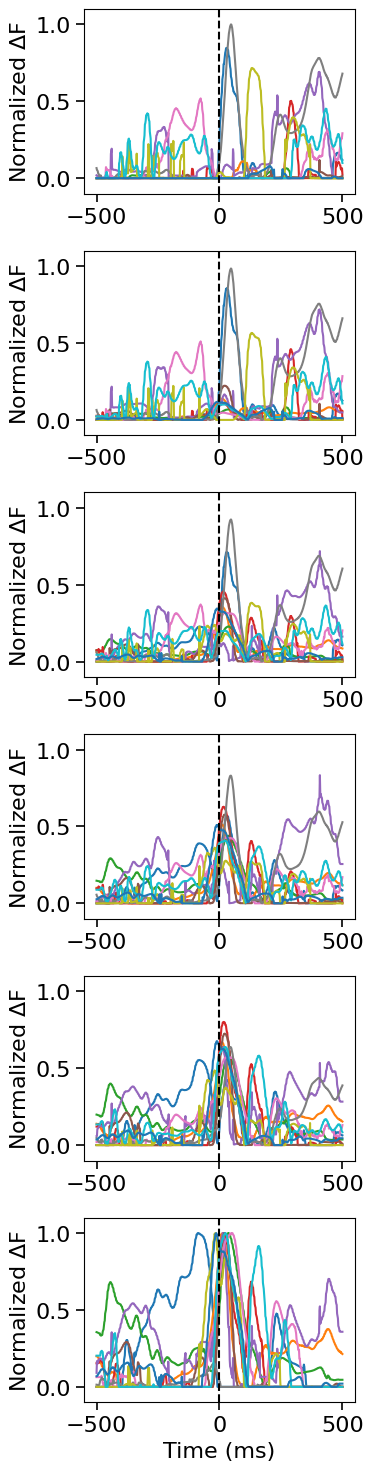

In [100]:
norm_m_layer_F_diff=np.zeros(aligned_subjects_m_layer_F_diff.shape)
for s_idx in range(aligned_subjects_m_layer_F_diff.shape[0]):
    subj_m_layer_F_diff=aligned_subjects_m_layer_F_diff[s_idx,:,:]
    norm_subj_m_layer_F_diff=subj_m_layer_F_diff/np.nanmax(subj_m_layer_F_diff[:])
    norm_m_layer_F_diff[s_idx,:,:]=norm_subj_m_layer_F_diff
plt.figure(figsize=(4,2.5*6))
for l_idx in range(norm_m_layer_F_diff.shape[1]):
    plt.subplot(6,1,l_idx+1)
    plt.plot(woi_win, norm_m_layer_F_diff[:,l_idx,:].T)
    plt.ylim([-0.1,1.1])
    plt.axvline(0,color='k',linestyle='--')
    plt.ylabel(r"Normalized $\Delta$F")
plt.xlabel('Time (ms)')
plt.tight_layout()
plt.savefig('./figure_SX_mf_aligned_individual_subjects.pdf')